# TUGAS MINGGU 4 : Exploratory Data Analysis (EDA) pada Dataset Dunia Nyata

Import primary modules.

In [33]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Data Understanding

## 1.1 Konteks Dataset
Dataset House Rent berisi informasi mengenai harga sewa properti di berbagai kota di India. 
Dataset ini digunakan untuk menganalisis faktor-faktor yang mempengaruhi harga sewa, seperti ukuran rumah, lokasi, dan fasilitas.

In [34]:
# load dataset
df = pd.read_csv('House_Rent_Dataset.csv')

print("Data berhasil dimuat")
df.head()

Data berhasil dimuat


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## 1.2 Dimensi Data

In [35]:
# Menampilkan dimensi data
print(df.shape)

(4746, 12)


Dataset memiliki 4746 baris dan 12 kolom.

## 1.3 Tipe Variabel

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


## 1.4 Penjelasan Variabel

- **BHK**: Jumlah kamar tidur
- **Rent**: Harga sewa per bulan
- **Size**: Luas rumah (sqft)
- **City**: Kota lokasi properti
- **Furnishing Status**: Status furnitur
- **Bathroom**: Jumlah kamar mandi

Dataset terdiri dari variabel numerik seperti Rent, Size, dan Bathroom, serta variabel kategorik seperti City dan Furnishing Status.

## 2. Data Cleaning

In [37]:
# cek missing value
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

Karena tidak ditemukan missing values pada dataset, maka tidak dilakukan proses penghapusan maupun imputasi data.
Hal ini menunjukkan bahwa dataset sudah dalam kondisi lengkap dan siap untuk dianalisis lebih lanjut tanpa perlu penanganan khusus terkait missing values.

In [38]:
# Deteksi duplikasi
df.duplicated().sum()

np.int64(0)

Hasil menunjukkan bahwa tidak terdapat data duplikat (0 data duplikat). 
Hal ini menandakan bahwa setiap baris data bersifat unik dan tidak ada pengulangan data yang dapat menyebabkan bias dalam analisis.

In [39]:
# Identifikasi Inkonsistensi Data
print(df['Area Type'].unique())
print(df['Furnishing Status'].unique())

<StringArray>
['Super Area', 'Carpet Area', 'Built Area']
Length: 3, dtype: str
<StringArray>
['Unfurnished', 'Semi-Furnished', 'Furnished']
Length: 3, dtype: str


Semua kolom kategorikal yang diperiksa (Area Type dan Furnishing Status) tidak memiliki inkonsistensi; nilai-nilainya konsisten dan siap digunakan untuk analisis lebih lanjut.

## Kesimpulan Data Cleaning

Tahapan data cleaning yang dilakukan pada dataset adalah sebagai berikut:

1. Pengecekan missing values menunjukkan bahwa tidak terdapat nilai yang hilang pada seluruh variabel.
2. Tidak ditemukan data duplikat dalam dataset.
3. Tidak ditemukan inkonsistensi data pada variabel kategorik.
4. Dataset telah berada dalam kondisi bersih dan siap untuk dilakukan analisis eksploratif (EDA).

## 3. Univariate Analysis

### Variabel Numerik

In [40]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


Variabel BHK memiliki rata-rata sekitar 2 kamar dengan median 2, menunjukkan bahwa mayoritas rumah memiliki 2 kamar tidur dan distribusinya relatif normal.

Variabel Rent memiliki perbedaan signifikan antara mean dan median, yang menunjukkan distribusi miring ke kanan (right-skewed). Hal ini disebabkan adanya beberapa nilai ekstrem dengan harga sangat tinggi, serta standar deviasi yang besar menunjukkan variasi harga yang tinggi.

Variabel Size menunjukkan bahwa sebagian besar rumah memiliki luas sekitar 850–1200, namun terdapat outlier dengan ukuran sangat besar.

Variabel Bathroom memiliki rata-rata sekitar 2 dan median 2, yang menunjukkan mayoritas rumah memiliki 1–2 kamar mandi, namun terdapat beberapa nilai ekstrem.

### Histogram dan KDE

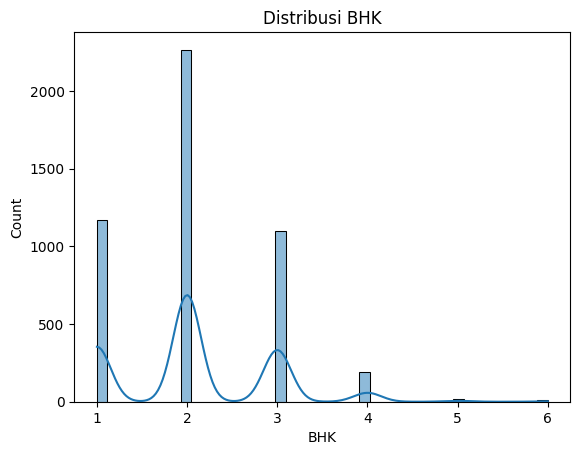

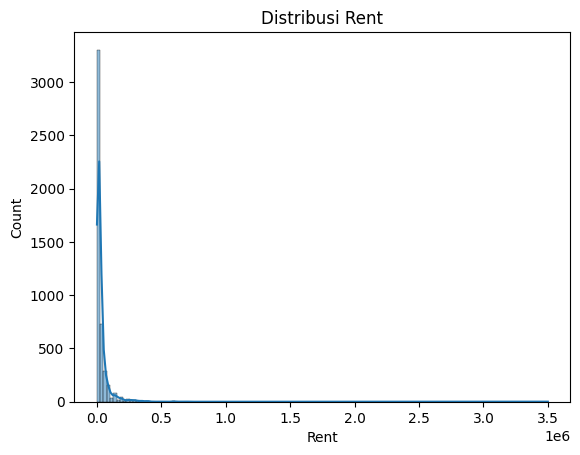

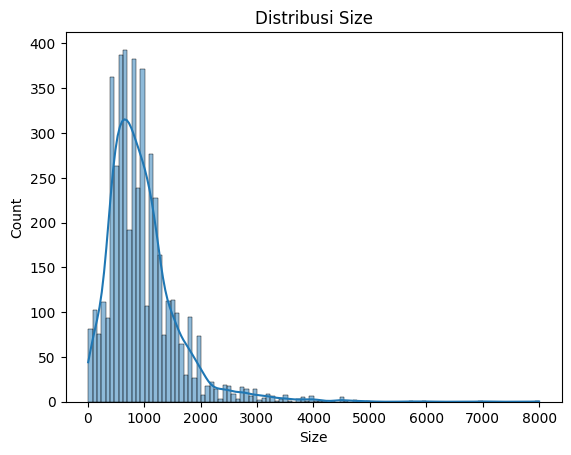

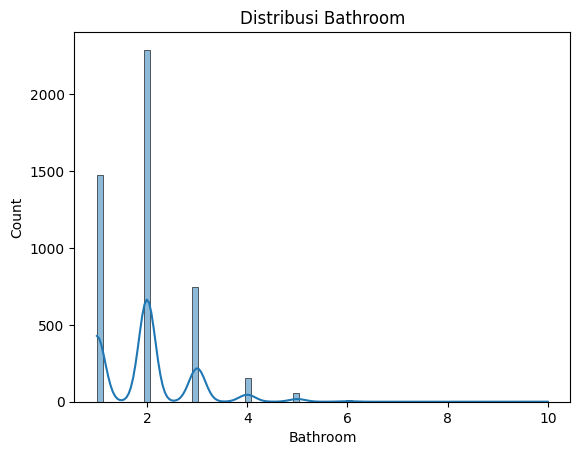

In [41]:
num_cols = ['BHK', 'Rent', 'Size', 'Bathroom']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi {col}")
    plt.show()

Histogram menunjukkan bahwa variabel Rent dan Size memiliki distribusi yang cenderung miring ke kanan, yang menandakan adanya nilai tinggi (outlier).

Variabel BHK dan Bathroom memiliki distribusi yang lebih terpusat pada nilai tertentu, terutama di angka 2, yang menunjukkan mayoritas data berada di nilai tersebut.

### Boxplot (Deteksi Outlier)

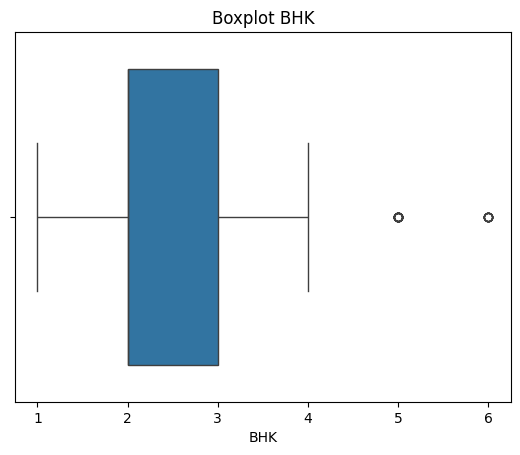

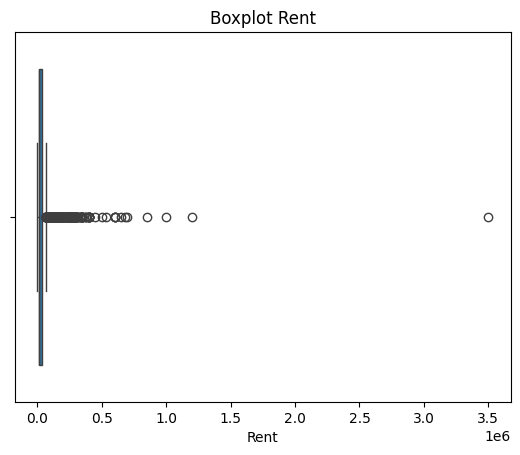

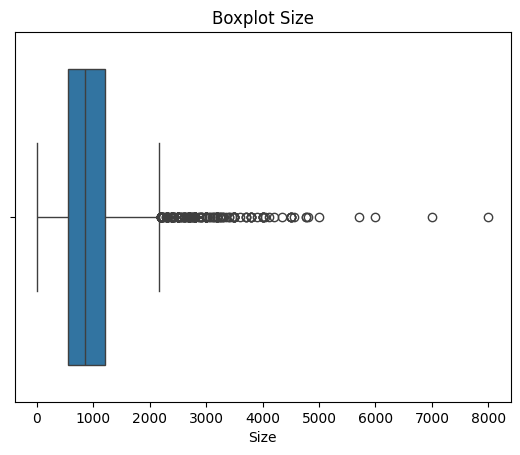

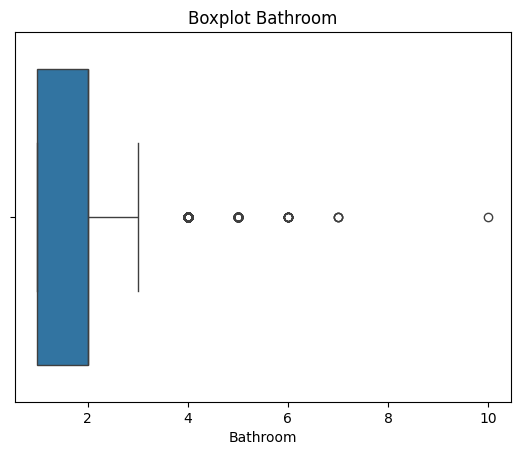

In [42]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

Boxplot menunjukkan adanya outlier pada variabel Rent, Size, dan Bathroom, yang terlihat dari titik-titik yang berada di luar whisker.

Variabel BHK tidak menunjukkan outlier yang signifikan dan memiliki distribusi yang lebih stabil.

### Variabel Kategori

### Frequency Table

In [43]:
cat_cols = ['Area Type', 'Furnishing Status', 'City']

for col in cat_cols:
    print(df[col].value_counts())
    print()

Area Type
Super Area     2446
Carpet Area    2298
Built Area        2
Name: count, dtype: int64

Furnishing Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680
Name: count, dtype: int64

City
Mumbai       972
Chennai      891
Bangalore    886
Hyderabad    868
Delhi        605
Kolkata      524
Name: count, dtype: int64



Area Type : Mayoritas data berada pada kategori Super Area dan Carpet Area, sedangkan Built Area sangat sedikit sehingga kurang signifikan.
Furnishing Status : Sebagian besar rumah berstatus Semi-Furnished, diikuti Unfurnished, dan paling sedikit Furnished.
City : Kota dengan data terbanyak adalah Mumbai, diikuti beberapa kota lain dengan jumlah yang relatif seimbang, sementara beberapa kota memiliki data lebih sedikit.

### Bar Chart

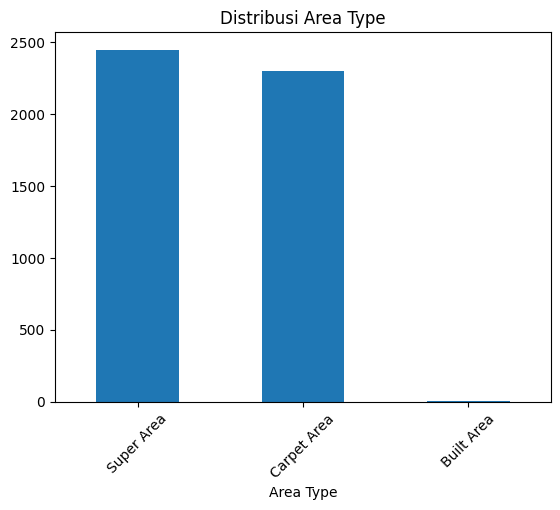

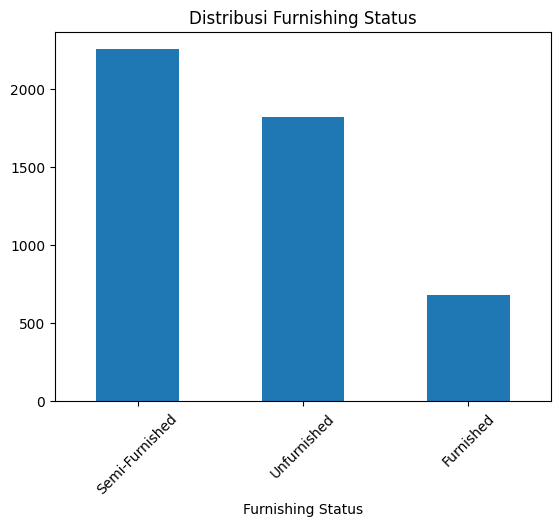

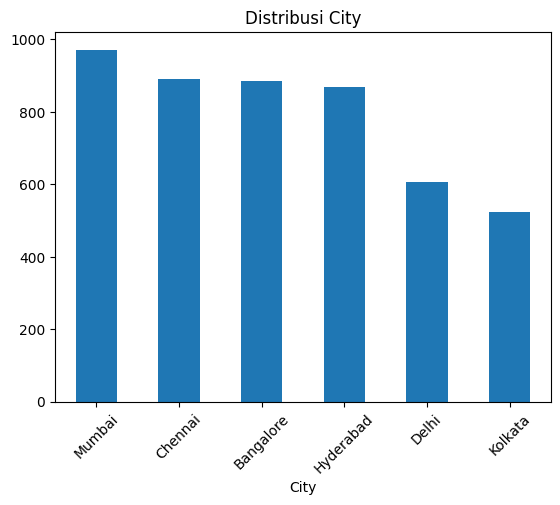

In [44]:
for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribusi {col}")
    plt.xticks(rotation=45)
    plt.show()

Bar chart menunjukkan bahwa distribusi data pada variabel kategorik tidak merata, di mana Super Area dan Carpet Area mendominasi pada Area Type, Semi-Furnished paling banyak pada Furnishing Status, serta Mumbai memiliki jumlah data terbanyak dibandingkan kota lainnya.

## 4. Bivariate Analysis

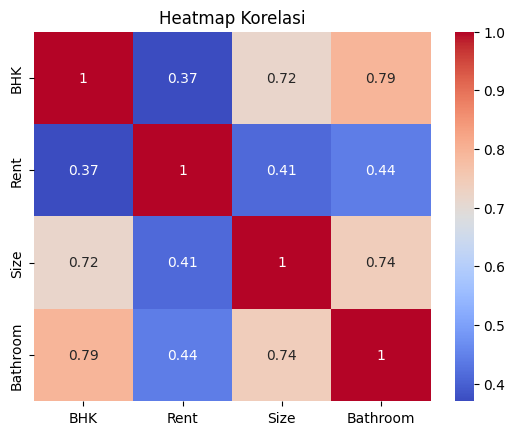

In [45]:
# Korelasi Antar Variabel Numerik (Heatmap)
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi")
plt.show()

Hasil heatmap menunjukkan bahwa variabel Size memiliki korelasi paling kuat dengan Rent, yang berarti semakin besar luas rumah maka harga sewa cenderung meningkat. Variabel lain seperti BHK dan Bathroom memiliki korelasi yang lebih lemah.

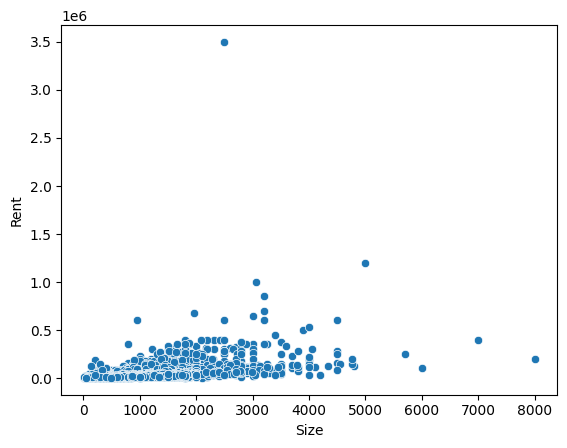

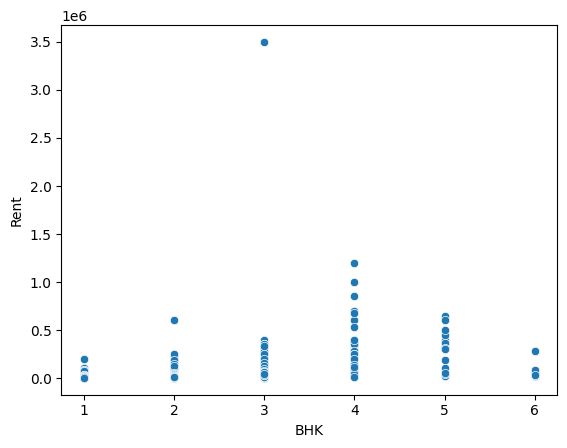

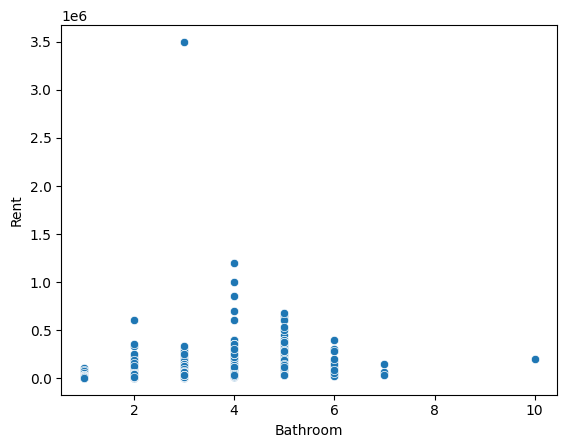

In [46]:
# Scatter Plot (3 Pasang Variabel)
sns.scatterplot(x='Size', y='Rent', data=df)
plt.show()

sns.scatterplot(x='BHK', y='Rent', data=df)
plt.show()

sns.scatterplot(x='Bathroom', y='Rent', data=df)
plt.show()

Scatter plot antara Size dan Rent menunjukkan pola positif yang cukup jelas, menandakan hubungan linear.

Hubungan antara BHK dan Rent serta Bathroom dan Rent juga menunjukkan tren positif, namun tidak sekuat Size, dengan pola yang lebih menyebar.

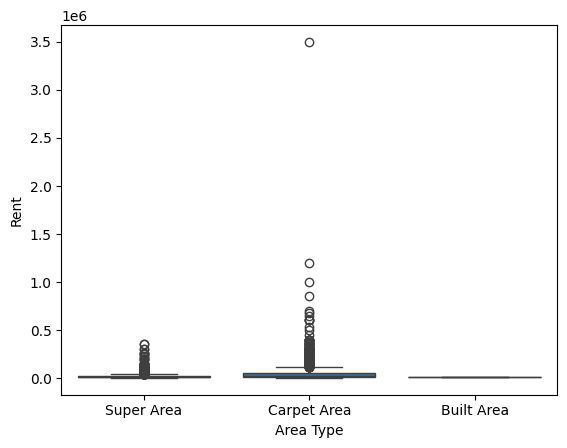

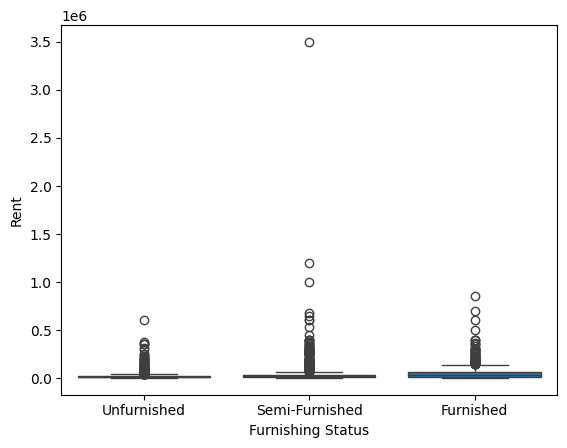

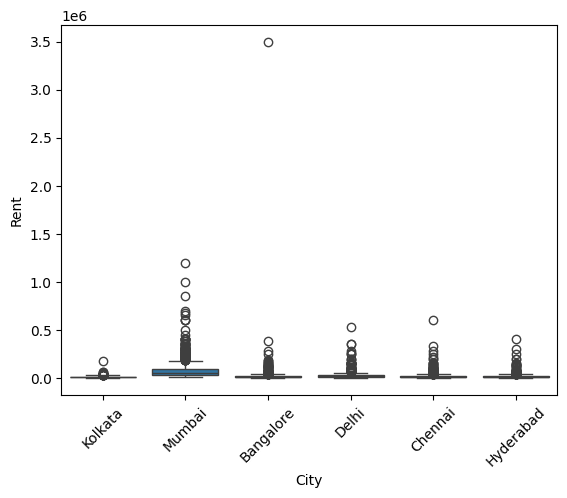

In [47]:
# Perbandingan Distribusi (Boxplot)
sns.boxplot(x='Area Type', y='Rent', data=df)
plt.show()

sns.boxplot(x='Furnishing Status', y='Rent', data=df)
plt.show()

sns.boxplot(x='City', y='Rent', data=df)
plt.xticks(rotation=45)
plt.show()

Boxplot menunjukkan bahwa harga sewa bervariasi berdasarkan kategori. Beberapa kategori memiliki median yang lebih tinggi, serta terdapat outlier pada hampir semua kategori, terutama pada variabel Rent.

### Pertanyaan

1. Variabel dengan hubungan kuat

Jawaban : Variabel yang memiliki hubungan paling kuat adalah Size terhadap Rent, karena menunjukkan korelasi tertinggi dibandingkan variabel lainnya.

2. Apakah terdapat pola linear / non-linear?

Jawaban : Terdapat pola linear positif, terutama antara Size dan Rent, di mana semakin besar ukuran rumah maka harga sewa semakin tinggi. Namun, pada variabel lain pola cenderung lebih lemah dan menyebar (tidak terlalu jelas).

## 5. Multivariate Analysis (Pairplot)

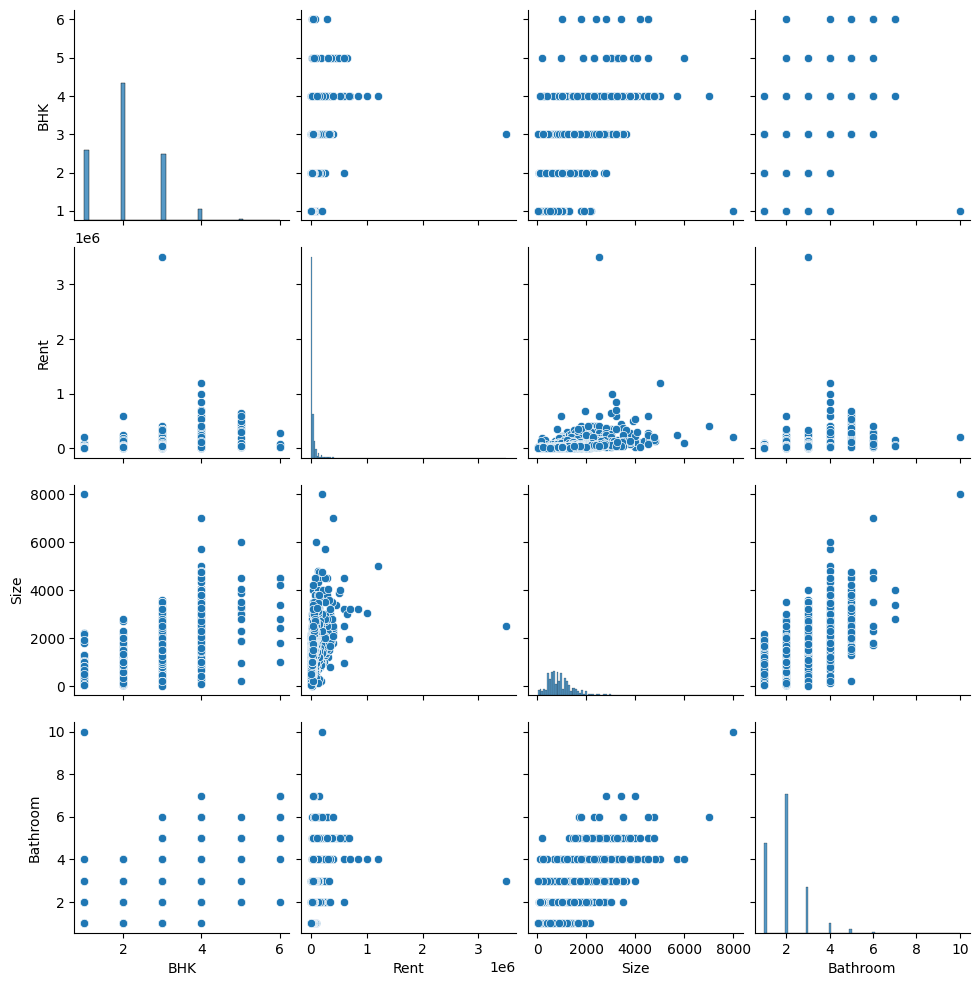

In [48]:
#pairplot
sns.pairplot(df[['BHK', 'Rent', 'Size', 'Bathroom']])
plt.show()

Pairplot menunjukkan hubungan antar variabel numerik secara keseluruhan. Terlihat bahwa Size memiliki hubungan paling jelas dengan Rent, dengan pola yang cenderung linear positif.

Variabel BHK dan Bathroom juga menunjukkan hubungan positif terhadap Rent, namun tidak sekuat Size. Selain itu, terlihat adanya penyebaran data yang cukup luas pada variabel Rent, yang mengindikasikan adanya outlier.

Secara umum, semakin besar ukuran rumah dan semakin banyak fasilitas (kamar tidur dan kamar mandi), maka harga sewa cenderung meningkat.

## 6. Kesimpulan

Berdasarkan hasil analisis, pola utama dalam data menunjukkan bahwa harga sewa rumah cenderung meningkat seiring dengan bertambahnya luas rumah (Size), jumlah kamar tidur (BHK), dan jumlah kamar mandi (Bathroom). Namun, distribusi harga sewa tidak merata karena adanya beberapa nilai ekstrem (outlier) yang sangat tinggi.

Variabel yang paling berpengaruh terhadap harga sewa adalah Size, karena memiliki hubungan paling kuat dan pola yang cenderung linear positif dibandingkan variabel lainnya.

Selain itu, terdapat indikasi segmentasi alami dalam data, di mana rumah dengan ukuran kecil hingga sedang berada pada rentang harga lebih rendah, sedangkan rumah dengan ukuran besar cenderung memiliki harga sewa yang jauh lebih tinggi.